# BD_P04: NoSQL dan Pemodelan Data

## K-1. Menyiapkan Lingkungan dan Data Contoh

Pada sel di bawah, kita menginstal pustaka yang diperlukan (`duckdb`, `networkx`, `shapely`, `tinydb`, `deltalake`) dan menghubungkan Google Drive untuk mengakses data praktikum sebelumnya.

In [1]:
!pip install -q duckdb networkx shapely tinydb "deltalake>=1.0"
from google.colab import drive
drive.mount("/content/drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.7 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
import os, time, json, sqlite3, random, shutil, glob
import numpy as np, pandas as pd
import pyarrow.dataset as ds

DIR_P3 = "/content/drive/MyDrive/BigData/Praktikum3"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum4"
os.makedirs(DIR_SIMPAN, exist_ok=True)

# Hasil Praktikum 3 (K-10): folder trips_bersih/ atau, bila yang tersimpan di Drive hanya arsipnya, trips_bersih.zip
TRIPS_BERSIH = f"{DIR_P3}/trips_bersih"
ZIP_P3 = f"{DIR_P3}/trips_bersih.zip"
if not os.path.exists(TRIPS_BERSIH) and os.path.exists(ZIP_P3):
    TRIPS_BERSIH = "/content/trips_bersih"          # diekstrak ke disk lokal Colab
    shutil.rmtree(TRIPS_BERSIH, ignore_errors=True)
    shutil.unpack_archive(ZIP_P3, TRIPS_BERSIH)
assert os.path.exists(TRIPS_BERSIH), "Folder trips_bersih/ tidak ada. Jalankan ulang P3/K-10."

# Pengukur waktu (dari Praktikum 1/K-3, versi ringkas)
catatan = []
def ukur(label, fungsi):
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 4)})
    print(f"[{label}] {detik:.4f} s")
    return hasil

def sama_hasil(a, b, tol=0.011):
    """Bandingkan dua daftar (wilayah, jumlah, rata-rata); selisih pembulatan 1 sen dianggap sama."""
    a, b = [tuple(x) for x in a], [tuple(x) for x in b]
    return len(a) == len(b) and all(x[0] == y[0] and x[1] == y[1] and abs(x[2] - y[2]) <= tol for x, y in zip(a, b))

# partitioning hive tanpa dictionary: partisi null (zona di luar NYC) tidak membuat pembacaan error
df = ukur("baca trips_bersih", lambda: pd.read_parquet(TRIPS_BERSIH, partitioning=ds.partitioning(flavor="hive")))

# Ganti nama kolom asli data TLC menjadi nama yang lebih mudah dibaca
NAMA_BARU = {
    "tpep_pickup_datetime": "waktu_jemput",
    "PULocationID": "zona_jemput",
    "DOLocationID": "zona_tujuan",
    "borough_naik": "wilayah_jemput",
    "trip_distance": "jarak_mil",
    "total_amount": "total_bayar",
    "tip_amount": "tip",
    "nama_pembayaran": "metode_bayar",
}
df = df.rename(columns=NAMA_BARU)
w_ = df["wilayah_jemput"]
df["wilayah_jemput"] = w_.astype(object).where(w_.notna(), "N/A").astype(str)   # wilayah kosong diberi label "N/A"
print("baris:", f"{len(df):,}", "| kolom:", df.shape[1])

# Contoh 300.000 baris untuk K-2 dan K-3 (agar tidak terlalu lama)
sample = df.sample(n=min(300_000, len(df)), random_state=42).reset_index(drop=True)
sample["id_perjalanan"] = sample.index + 1
sample["waktu_jemput"] = sample["waktu_jemput"].astype(str)

[baca trips_bersih] 2.0278 s
baris: 2,986,910 | kolom: 18


## K-2. Tabel Biasa vs Key-value

Bagian ini membandingkan kinerja pencarian data tunggal dan agregasi data antara model relasional (SQLite) dan model Key-Value (Python dictionary dengan nilai JSON).

### Eksperimen K-2: Pengujian Performa SQLite vs Key-Value

Sel di bawah ini memuat data ke SQLite, membangun struktur data key-value di memori, dan menguji kecepatan pencarian data acak (dengan dan tanpa indeks) serta kecepatan operasi pengelompokan (GROUP BY).

In [3]:
KOLOM = ["id_perjalanan", "waktu_jemput", "zona_jemput", "zona_tujuan",
         "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data = sample[KOLOM].copy()

# Model 1 - relasional: tabel SQLite
if os.path.exists("uji.db"):
    os.remove("uji.db")
con = sqlite3.connect("uji.db")
ukur("relasional: muat tabel", lambda: data.to_sql("perjalanan", con, index=False))

# Model 2 - key-value: kamus (dict) dengan kunci "perjalanan:<id>", nilainya teks JSON
def bangun_kv():
    return {f"perjalanan:{r['id_perjalanan']}": json.dumps(r) for r in data.to_dict("records")}
kv = ukur("key-value: bangun dict", bangun_kv)
print("jumlah key:", len(kv))

# Pertanyaan A: ambil SATU perjalanan berdasarkan id (200 id acak)
random.seed(42)
id_uji = random.sample(range(1, len(data) + 1), 200)
def cari_sql():
    cur = con.cursor()
    return [cur.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_uji]
def cari_kv():
    return [json.loads(kv[f"perjalanan:{i}"]) for i in id_uji]

r1 = ukur("cari 200 perjalanan - SQL tanpa indeks", cari_sql)
con.execute("CREATE INDEX idx_id ON perjalanan(id_perjalanan)")   # buat indeks
r2 = ukur("cari 200 perjalanan - SQL dengan indeks", cari_sql)
r3 = ukur("cari 200 perjalanan - key-value", cari_kv)
print("hasil sama?", r1[0][0] == r2[0][0] == r3[0]["id_perjalanan"])

# Pertanyaan B: hitung rata-rata total bayar per wilayah (melibatkan SEMUA data)
def hitung_sql():
    return con.execute("""SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
                          FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1""").fetchall()
def hitung_kv():
    total, jumlah = {}, {}
    for teks in kv.values():
        d = json.loads(teks)                      # setiap nilai harus dibuka dulu
        w = d["wilayah_jemput"]
        total[w] = total.get(w, 0) + d["total_bayar"]
        jumlah[w] = jumlah.get(w, 0) + 1
    return sorted([(w, jumlah[w], round(total[w] / jumlah[w], 2)) for w in jumlah],
                  key=lambda x: (-x[1], x[0]))

h1 = ukur("hitung per wilayah - SQL GROUP BY", hitung_sql)
h2 = ukur("hitung per wilayah - key-value (buka semua nilai)", hitung_kv)
print(h1[:3])
print("hasil sama?", sama_hasil(h1, h2))

[relasional: muat tabel] 0.5578 s
[key-value: bangun dict] 1.8239 s
jumlah key: 300000
[cari 200 perjalanan - SQL tanpa indeks] 4.6186 s
[cari 200 perjalanan - SQL dengan indeks] 0.0041 s
[cari 200 perjalanan - key-value] 0.0035 s
hasil sama? True
[hitung per wilayah - SQL GROUP BY] 0.3616 s
[hitung per wilayah - key-value (buka semua nilai)] 1.1004 s
[('Manhattan', 267034, 22.7), ('Queens', 27288, 70.34), ('Unknown', 3787, 39.13)]
hasil sama? True


## K-3. Document: Bentuk Data yang Fleksibel

Model dokumen sangat cocok untuk menangani data semi-terstruktur atau memiliki atribut yang opsional tanpa perlu melakukan perubahan skema tabel (skema fleksibel).

### Eksperimen K-3: Transformasi ke Format Dokumen dan Penyimpanan ke TinyDB

Sel berikut mengonversi baris data mentah menjadi dokumen JSON bersarang (nested) di mana field 'tip' hanya disimpan untuk metode pembayaran kartu kredit, lalu menyimpannya ke database berbasis dokumen TinyDB di memori.

In [4]:
from tinydb import TinyDB, Query
from tinydb.storages import MemoryStorage

def ke_dokumen(r):
    dok = {
        "id_perjalanan": int(r.id_perjalanan),
        "waktu_jemput": r.waktu_jemput,
        "jemput": {"zona": int(r.zona_jemput), "wilayah": r.wilayah_jemput},
        "tujuan": {"zona": int(r.zona_tujuan)},
        "biaya": {"jarak_mil": float(r.jarak_mil),
                  "total": float(r.total_bayar),
                  "metode_bayar": r.metode_bayar},
    }
    # Tip hanya dicatat untuk pembayaran kartu -> field ini ada di sebagian dokumen saja
    if r.metode_bayar == "Kartu kredit":
        dok["biaya"]["tip"] = float(r.tip)
    return dok

db = TinyDB(storage=MemoryStorage)
tabel = db.table("perjalanan")
docs = [ke_dokumen(r) for r in sample.head(20_000).itertuples()]
tabel.insert_multiple(docs)
print("jumlah dokumen:", len(tabel))
print(json.dumps(tabel.all()[0], indent=2))

jumlah dokumen: 20000
{
  "id_perjalanan": 1,
  "waktu_jemput": "2023-01-16 10:40:39",
  "jemput": {
    "zona": 48,
    "wilayah": "Manhattan"
  },
  "tujuan": {
    "zona": 164
  },
  "biaya": {
    "jarak_mil": 1.55,
    "total": 19.32,
    "metode_bayar": "Kartu kredit",
    "tip": 3.22
  }
}


In [5]:
Q = Query()
print("jemput di Manhattan & total > 50 :", len(tabel.search((Q.jemput.wilayah == "Manhattan") & (Q.biaya.total > 50))))
print("dokumen yang punya field tip     :", len(tabel.search(Q.biaya.tip.exists())))
print("dokumen yang TIDAK punya tip     :", len(tabel.search(~Q.biaya.tip.exists())))

# Menambah field baru ("cuaca") pada satu dokumen - tanpa mengubah struktur apa pun
tabel.insert({"id_perjalanan": 999_999, "waktu_jemput": "2023-01-15 08:00:00",
              "jemput": {"zona": 161, "wilayah": "Manhattan"}, "tujuan": {"zona": 236},
              "biaya": {"jarak_mil": 1.2, "total": 14.5, "metode_bayar": "Kartu kredit", "tip": 3.0},
              "cuaca": {"hujan": True, "suhu_c": -2.0}})
print("dokumen yang punya field cuaca   :", len(tabel.search(Q.cuaca.exists())))
print("total dokumen sekarang           :", len(tabel))

jemput di Manhattan & total > 50 : 693
dokumen yang punya field tip     : 15906
dokumen yang TIDAK punya tip     : 4094
dokumen yang punya field cuaca   : 1
total dokumen sekarang           : 20001


## K-4. Penyimpanan per Kolom: DuckDB pada Parquet

Penyimpanan berorientasi kolom sangat efisien untuk proses analitik (OLAP) karena hanya membaca kolom-kolom yang diperlukan dalam kueri (column pruning).

### Eksperimen K-4: Analisis Data Menggunakan DuckDB Langsung dari File Parquet

Sel di bawah membuat tampilan virtual (VIEW) di DuckDB yang mengarah langsung ke file Parquet hasil pembersihan, melakukan query agregasi yang sangat cepat, dan membandingkan performanya dengan database tradisional berbasis baris (SQLite).

In [6]:
import duckdb

GLOB = f"{TRIPS_BERSIH}/*/*.parquet"
con_d = duckdb.connect()

# VIEW = "jendela" bernama yang membaca Parquet langsung (tidak menyalin data).
# Di sinilah nama kolom asli TLC diberi nama yang mudah dibaca.
con_d.sql(f"""
    CREATE VIEW perjalanan AS
    SELECT tpep_pickup_datetime AS waktu_jemput,
           PULocationID  AS zona_jemput,
           DOLocationID  AS zona_tujuan,
           borough_naik  AS wilayah_jemput,
           trip_distance AS jarak_mil,
           total_amount  AS total_bayar,
           nama_pembayaran AS metode_bayar
    FROM read_parquet('{GLOB}', hive_partitioning=true)""")

SQL = """SELECT wilayah_jemput, COUNT(*) AS jumlah, ROUND(AVG(total_bayar), 2) AS rata_bayar
         FROM perjalanan GROUP BY wilayah_jemput ORDER BY jumlah DESC, wilayah_jemput"""
hasil_d = ukur("DuckDB - hitung per wilayah (langsung dari Parquet)", lambda: con_d.sql(SQL).df())
hasil_d["wilayah_jemput"] = hasil_d["wilayah_jemput"].fillna("N/A").replace("__HIVE_DEFAULT_PARTITION__", "N/A")   # partisi null -> label yang sama dengan K-1 (versi DuckDB tertentu mengembalikan teks ini, bukan NULL)
print(hasil_d)

# Pembanding: SQLite (menyimpan per baris) pada data yang sama
KOLOM_S = ["wilayah_jemput", "total_bayar", "jarak_mil", "zona_jemput", "zona_tujuan"]
if os.path.exists("baris.db"):
    os.remove("baris.db")
con_s = sqlite3.connect("baris.db")
ukur("SQLite - muat seluruh baris ke tabel", lambda: df[KOLOM_S].to_sql("perjalanan", con_s, index=False))
hasil_s = ukur("SQLite - hitung per wilayah", lambda: con_s.execute(
    """SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
       FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1""").fetchall())
print("hasil sama?", sama_hasil(hasil_d.itertuples(index=False), hasil_s))

[DuckDB - hitung per wilayah (langsung dari Parquet)] 0.0680 s
  wilayah_jemput   jumlah  rata_bayar
0      Manhattan  2659609       22.72
1         Queens   270315       70.46
2        Unknown    37609       39.24
3       Brooklyn    15724       32.72
4          Bronx     3074       34.44
5            N/A      340       74.72
6  Staten Island      211       74.07
7            EWR       28      106.41
[SQLite - muat seluruh baris ke tabel] 4.1025 s
[SQLite - hitung per wilayah] 1.0693 s
hasil sama? True


In [7]:
# Filter pada kolom partisi: DuckDB hanya membuka folder wilayah yang diminta (partition pruning, P3)
SQL2 = """SELECT COUNT(*), ROUND(AVG(total_bayar), 2)
          FROM perjalanan WHERE wilayah_jemput = 'Staten Island'"""
print(ukur("DuckDB - hanya wilayah Staten Island", lambda: con_d.sql(SQL2).fetchall()))

ukuran_pq = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(TRIPS_BERSIH) for f in fs) / 1024**2
print(f"Parquet ({df.shape[1]} kolom): {ukuran_pq:.1f} MB | SQLite ({len(KOLOM_S)} kolom): {os.path.getsize('baris.db') / 1024**2:.1f} MB")

[DuckDB - hanya wilayah Staten Island] 0.0151 s
[(211, 74.07)]
Parquet (18 kolom): 66.5 MB | SQLite (5 kolom): 114.2 MB


## K-5. Graph: Pertanyaan tentang Keterhubungan

Struktur graf (Graph) sangat unggul untuk menganalisis hubungan, rute, atau jalur multi-langkah antar entitas (node) dibandingkan dengan query SQL self-join tradisional.

### Eksperimen K-5: Representasi Jaringan Perjalanan menggunakan NetworkX

Sel di bawah menghitung volume arus perjalanan antar zona taksi, memodelkannya ke dalam objek graf berarah (DiGraph) menggunakan pustaka `networkx`, serta menganalisis zona-zona tujuan paling populer.

In [8]:
import networkx as nx

# Satu baris = satu arus: berapa perjalanan dari zona jemput ke zona tujuan tertentu
arus = ukur("hitung arus antar zona", lambda: con_d.sql("""
    SELECT zona_jemput AS asal, zona_tujuan AS tujuan, COUNT(*) AS jumlah
    FROM perjalanan GROUP BY 1, 2""").df())

# Zona = node (titik), arus = edge (garis berarah, bobotnya jumlah perjalanan)
G = nx.DiGraph()
for r in arus.itertuples(index=False):
    G.add_edge(int(r.asal), int(r.tujuan), jumlah=int(r.jumlah))
print("node (zona):", G.number_of_nodes(), "| edge (arus):", G.number_of_edges())

# Lima arus terbesar. Urutan dibuat pasti dengan pengurut tambahan (jumlah, asal, tujuan)
top_graf = sorted(G.edges(data=True), key=lambda e: (-e[2]["jumlah"], e[0], e[1]))[:5]
print("graph:", [(a, b, d["jumlah"]) for a, b, d in top_graf])
top_sql = arus.sort_values(["jumlah", "asal", "tujuan"], ascending=[False, True, True]).head(5)
print("SQL  :", list(top_sql.itertuples(index=False, name=None)))

# Lima zona yang paling banyak menjadi tujuan
populer = sorted(G.in_degree(weight="jumlah"), key=lambda kv: (-kv[1], kv[0]))[:5]
print("zona tujuan terpopuler:", populer)

[hitung arus antar zona] 0.1226 s
node (zona): 262 | edge (arus): 21583
graph: [(237, 236, 22065), (236, 237, 18810), (236, 236, 14110), (237, 237, 13753), (264, 264, 13562)]
SQL  : [(237, 236, 22065), (236, 237, 18810), (236, 236, 14110), (237, 237, 13753), (264, 264, 13562)]
zona tujuan terpopuler: [(236, 144209), (237, 130369), (161, 113991), (230, 87706), (170, 87110)]


In [9]:
MIN = 50                       # abaikan arus yang terlalu jarang (kurang dari 50 perjalanan)
zona_awal = populer[0][0]      # mulai dari zona tujuan terpopuler

# Pertanyaan: zona mana yang bisa dicapai dalam TEPAT 2 langkah dari zona_awal?
# (1) cara graph: telusuri tetangga dari tetangga
def dua_langkah_graph():
    hasil = set()
    for b, d1 in G[zona_awal].items():
        if d1["jumlah"] < MIN:
            continue
        for c, d2 in G[b].items():
            if d2["jumlah"] >= MIN and c != zona_awal:
                hasil.add(c)
    return hasil

# (2) cara SQL: harus menggabungkan tabel arus dengan dirinya sendiri (self-join)
con_d.register("arus", arus)
def dua_langkah_sql():
    return set(con_d.sql(f"""
        SELECT DISTINCT a2.tujuan
        FROM arus a1 JOIN arus a2 ON a1.tujuan = a2.asal
        WHERE a1.asal = {zona_awal} AND a1.jumlah >= {MIN}
          AND a2.jumlah >= {MIN} AND a2.tujuan <> {zona_awal}""").df()["tujuan"])

hg = ukur("2 langkah - graph (NetworkX)", dua_langkah_graph)
hs = ukur("2 langkah - SQL self-join (DuckDB)", dua_langkah_sql)
print("zona awal:", zona_awal, "| terjangkau (graph):", len(hg), "| (SQL):", len(hs), "| sama?", hg == hs)

# (3) Jumlah langkah bebas: "dalam paling banyak k langkah" - cukup ganti angka k
H = nx.DiGraph([(a, b) for a, b, d in G.edges(data=True) if d["jumlah"] >= MIN])
for k in (1, 2, 3, 4):
    n = len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1
    print(f"dalam <= {k} langkah: {n} zona")

[2 langkah - graph (NetworkX)] 0.0060 s
[2 langkah - SQL self-join (DuckDB)] 0.0161 s
zona awal: 236 | terjangkau (graph): 214 | (SQL): 214 | sama? True
dalam <= 1 langkah: 74 zona
dalam <= 2 langkah: 214 zona
dalam <= 3 langkah: 214 zona
dalam <= 4 langkah: 214 zona


## K-6. Indeks Spasial

Pencarian koordinat geografis di dalam area tertentu membutuhkan struktur indeks spasial (seperti R-Tree atau STRtree) agar tidak perlu memindai dan memeriksa seluruh titik di bumi secara manual.

### Eksperimen K-6: Pencarian Radius Titik Koordinat dengan STRtree

Sel di bawah membuat data titik sintetis dalam jumlah besar, lalu membandingkan kecepatan pencarian titik di dalam 1.000 kotak area menggunakan loop Python biasa, pemfilteran NumPy, dan indeks spasial STRtree.

In [10]:
from shapely import STRtree, box, points

# CATATAN: data TLC 2023 hanya berisi ID zona, TANPA koordinat. Titik di bawah ini SINTETIS.
rng = np.random.default_rng(42)
N = 200_000
bujur = rng.normal(-73.97, 0.06, N).clip(-74.25, -73.70)    # longitude
lintang = rng.normal(40.74, 0.05, N).clip(40.50, 40.92)     # latitude
titik = points(bujur, lintang)

# 1.000 wilayah pencarian berupa kotak kecil (sekitar 1 km x 1 km)
M = 1000
cx = rng.uniform(-74.05, -73.85, M)
cy = rng.uniform(40.65, 40.85, M)
kotak = [box(x - 0.005, y - 0.005, x + 0.005, y + 0.005) for x, y in zip(cx, cy)]

# Cara 1: periksa titik satu per satu dengan loop Python (hanya 5 kotak, 1.000 akan sangat lama)
def cara_loop():
    return [sum(1 for p in titik if k.contains(p)) for k in kotak[:5]]

# Cara 2: bandingkan seluruh titik sekaligus dengan NumPy (tanpa indeks spasial), 1.000 kotak
def cara_numpy():
    hasil = []
    for x, y in zip(cx, cy):
        m = (bujur >= x - 0.005) & (bujur <= x + 0.005) & (lintang >= y - 0.005) & (lintang <= y + 0.005)
        hasil.append(int(m.sum()))
    return hasil

h_loop = ukur("cara 1 - loop Python, 5 kotak", cara_loop)
h_np = ukur("cara 2 - NumPy, 1000 kotak", cara_numpy)

# Cara 3: indeks spasial STRtree (sejenis R-tree)
pohon = ukur("bangun indeks STRtree", lambda: STRtree(titik))
h_idx = ukur("cara 3 - STRtree, 1000 kotak",
             lambda: [len(pohon.query(k, predicate="contains")) for k in kotak])

print("5 kotak pertama - loop:", h_loop, "| STRtree:", h_idx[:5])
print("hasil NumPy dan STRtree sama?", h_np == h_idx, "| loop dan STRtree sama (5 pertama)?", h_loop == h_idx[:5])
print("total titik ditemukan (1000 kotak):", sum(h_idx))

[cara 1 - loop Python, 5 kotak] 8.1042 s
[cara 2 - NumPy, 1000 kotak] 0.2259 s
[bangun indeks STRtree] 0.0523 s
[cara 3 - STRtree, 1000 kotak] 0.2051 s
5 kotak pertama - loop: [1012, 84, 228, 748, 509] | STRtree: [1012, 84, 228, 748, 509]
hasil NumPy dan STRtree sama? True | loop dan STRtree sama (5 pertama)? True
total titik ditemukan (1000 kotak): 417545


## K-7. Delta Lake: Versi, Time Travel, dan Schema Enforcement

Delta Lake menambahkan kapabilitas ACID Transactions di atas penyimpanan data lake (Parquet), memungkinkan fitur seperti *time travel* (melihat riwayat data) dan proteksi kualitas data (*schema enforcement*).

### Eksperimen K-7: Penulisan Delta Table, Update Data, dan Validasi Skema

Sel di bawah ini menginisialisasi tabel Delta Lake, melakukan operasi append baru, melakukan update data bersyarat pada baris tertentu, dan memverifikasi bahwa perubahan versi tercatat dengan aman.

In [11]:
from deltalake import DeltaTable, write_deltalake

KOLOM_DELTA = ["waktu_jemput", "zona_jemput", "zona_tujuan",
               "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data_delta = df[KOLOM_DELTA].sample(n=min(200_000, len(df)), random_state=42).reset_index(drop=True)

PATH_DELTA = "/content/trips_delta"      # disk lokal Colab (Drive tidak mendukung rename yang dipakai Delta); diarsipkan ke Drive di akhir
if os.path.exists(PATH_DELTA):
    shutil.rmtree(PATH_DELTA)

# Versi 0: menulis data awal (100.000 baris)
write_deltalake(PATH_DELTA, data_delta.iloc[:100_000], mode="overwrite")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))

# Versi 1: menambah 50.000 baris
write_deltalake(PATH_DELTA, data_delta.iloc[100_000:150_000], mode="append")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))

# Versi 2: koreksi data. Anggap tarif Tunai di wilayah Bronx perlu ditambah 1.0
sekarang = data_delta.iloc[:150_000]
n_koreksi = int(((sekarang["wilayah_jemput"] == "Bronx") & (sekarang["metode_bayar"] == "Tunai")).sum())
print("baris yang akan dikoreksi:", n_koreksi)
dt.update(predicate="wilayah_jemput = 'Bronx' AND metode_bayar = 'Tunai'",
          updates={"total_bayar": "total_bayar + 1.0"})
print("versi:", DeltaTable(PATH_DELTA).version())

versi: 0 | baris: 100000
versi: 1 | baris: 150000
baris yang akan dikoreksi: 20
versi: 2


In [12]:
# TIME TRAVEL: baca tabel sebagaimana keadaannya pada versi tertentu
v0 = DeltaTable(PATH_DELTA, version=0).to_pandas()
v1 = DeltaTable(PATH_DELTA, version=1).to_pandas()
terbaru = DeltaTable(PATH_DELTA).to_pandas()
print("baris v0:", len(v0), "| v1:", len(v1), "| terbaru:", len(terbaru))
selisih = terbaru["total_bayar"].sum() - v1["total_bayar"].sum()
print("selisih total_bayar (terbaru - v1):", round(selisih, 2), "| jumlah baris dikoreksi:", n_koreksi)

# Riwayat perubahan tabel
for h in DeltaTable(PATH_DELTA).history():
    print(h.get("version"), h.get("operation"))

# Log transaksi: satu file JSON per versi
print(sorted(os.listdir(f"{PATH_DELTA}/_delta_log")))

# PENEGAKAN SKEMA: menambah data dengan kolom asing harus DITOLAK, tabel tidak berubah
tambahan = data_delta.iloc[150_000:150_010].copy()
tambahan["kolom_asing"] = 1
try:
    write_deltalake(PATH_DELTA, tambahan, mode="append")
    print("append kolom asing: BERHASIL (tidak diharapkan)")
except Exception as e:
    print("append kolom asing DITOLAK:", type(e).__name__)
print("versi setelah percobaan gagal:", DeltaTable(PATH_DELTA).version())

baris v0: 100000 | v1: 150000 | terbaru: 150000
selisih total_bayar (terbaru - v1): 20.0 | jumlah baris dikoreksi: 20
2 UPDATE
1 WRITE
0 WRITE
['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json']
append kolom asing DITOLAK: SchemaMismatchError
versi setelah percobaan gagal: 2


## K-8. Small File Problem pada Tabel Delta

Operasi penulisan berskala kecil yang terlalu sering dapat menciptakan ribuan file kecil yang menurunkan performa pembacaan data lake. Masalah ini diselesaikan dengan optimasi penggabungan file (*compaction*).

### Eksperimen K-8: Mensimulasikan File Kecil dan Melakukan Compaction (Optimize)

Sel di bawah ini mensimulasikan penulisan data secara berkala (20 kali append kecil), lalu menjalankan perintah `.optimize.compact()` untuk menggabungkannya kembali menjadi satu file besar guna meningkatkan performa baca.

In [13]:
dt = DeltaTable(PATH_DELTA)
print("file data aktif sebelum:", len(dt.file_uris()), "| versi:", dt.version())

# 20 kali menambah data kecil (500 baris) - seperti data yang masuk sedikit demi sedikit
for i in range(20):
    potongan = data_delta.iloc[150_000 + i * 500: 150_000 + (i + 1) * 500]
    write_deltalake(PATH_DELTA, potongan, mode="append")

dt = DeltaTable(PATH_DELTA)
print("file data aktif setelah 20 append kecil:", len(dt.file_uris()), "| versi:", dt.version(), "| baris:", len(dt.to_pandas()))
t0 = time.perf_counter(); _ = DeltaTable(PATH_DELTA).to_pandas(); t_sebelum = time.perf_counter() - t0

# COMPACTION: gabungkan file kecil menjadi file yang lebih besar (dicatat sebagai versi baru)
hasil = dt.optimize.compact()
print("hasil compact:", {k: hasil[k] for k in ("numFilesAdded", "numFilesRemoved")})

dt = DeltaTable(PATH_DELTA)
t0 = time.perf_counter(); _ = DeltaTable(PATH_DELTA).to_pandas(); t_sesudah = time.perf_counter() - t0
print("file data aktif setelah compact:", len(dt.file_uris()), "| versi:", dt.version(), "| baris:", len(dt.to_pandas()))
print(f"waktu baca sebelum compact: {t_sebelum:.4f} s | sesudah: {t_sesudah:.4f} s")

# File lama TIDAK langsung terhapus (masih dibutuhkan untuk time travel). VACUUM yang menghapusnya.
print("file parquet di disk:", len(glob.glob(f"{PATH_DELTA}/*.parquet")))
kandidat = dt.vacuum(retention_hours=0, enforce_retention_duration=False, dry_run=True)   # dry_run = hanya melaporkan
print("file yang akan dihapus VACUUM (dry run):", len(kandidat))

file data aktif sebelum: 1 | versi: 2
file data aktif setelah 20 append kecil: 21 | versi: 22 | baris: 160000
hasil compact: {'numFilesAdded': 1, 'numFilesRemoved': 21}
file data aktif setelah compact: 1 | versi: 23 | baris: 160000
waktu baca sebelum compact: 0.0469 s | sesudah: 0.0379 s
file parquet di disk: 24
file yang akan dihapus VACUUM (dry run): 23


> **Peringatan:** `retention_hours=0` bersama `dry_run=True` hanya dipakai untuk melihat cakupan VACUUM tanpa menghapus apa pun. Jangan menjalankan VACUUM dengan retention 0 jam (`dry_run=False`) pada tabel sungguhan.

## K-9. Merangkum dan Memilih

Pada bagian ini, kita mengumpulkan semua metrik performa waktu eksekusi dari eksperimen sebelumnya untuk menganalisis rasio perbandingan performa antar teknologi penyimpanan.

In [14]:
rekap = pd.DataFrame(catatan)
rekap.to_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv", index=False)
print(rekap.to_string(index=False))

                                            langkah  detik
                                  baca trips_bersih 2.0278
                             relasional: muat tabel 0.5578
                             key-value: bangun dict 1.8239
             cari 200 perjalanan - SQL tanpa indeks 4.6186
            cari 200 perjalanan - SQL dengan indeks 0.0041
                    cari 200 perjalanan - key-value 0.0035
                  hitung per wilayah - SQL GROUP BY 0.3616
  hitung per wilayah - key-value (buka semua nilai) 1.1004
DuckDB - hitung per wilayah (langsung dari Parquet) 0.0680
               SQLite - muat seluruh baris ke tabel 4.1025
                        SQLite - hitung per wilayah 1.0693
               DuckDB - hanya wilayah Staten Island 0.0151
                             hitung arus antar zona 0.1226
                       2 langkah - graph (NetworkX) 0.0060
                 2 langkah - SQL self-join (DuckDB) 0.0161
                      cara 1 - loop Python, 5 kotak 8.10

In [15]:
# Rasio waktu untuk mengisi kolom "Angka Anda" pada tabel rekap dan Analisis Hasil
w = {c["langkah"]: c["detik"] for c in catatan}
loop_1000 = w["cara 1 - loop Python, 5 kotak"] / 5 * 1000     # perkiraan, tidak dijalankan
butir = [
    ("Cari 200 id: SQL tanpa indeks / SQL berindeks", w["cari 200 perjalanan - SQL tanpa indeks"], w["cari 200 perjalanan - SQL dengan indeks"]),
    ("Cari 200 id: SQL berindeks / key-value", w["cari 200 perjalanan - SQL dengan indeks"], w["cari 200 perjalanan - key-value"]),
    ("Hitung per wilayah: key-value / SQL GROUP BY", w["hitung per wilayah - key-value (buka semua nilai)"], w["hitung per wilayah - SQL GROUP BY"]),
    ("Hitung per wilayah: SQLite / DuckDB", w["SQLite - hitung per wilayah"], w["DuckDB - hitung per wilayah (langsung dari Parquet)"]),
    ("Muat + hitung: (SQLite muat + hitung) / DuckDB", w["SQLite - muat seluruh baris ke tabel"] + w["SQLite - hitung per wilayah"], w["DuckDB - hitung per wilayah (langsung dari Parquet)"]),
    ("Dua langkah: SQL self-join / graph", w["2 langkah - SQL self-join (DuckDB)"], w["2 langkah - graph (NetworkX)"]),
    ("Spasial: loop Python (perkiraan 1.000 kotak) / STRtree cari", loop_1000, w["cara 3 - STRtree, 1000 kotak"]),
    ("Spasial: NumPy / STRtree cari", w["cara 2 - NumPy, 1000 kotak"], w["cara 3 - STRtree, 1000 kotak"]),
    ("Spasial: NumPy / (STRtree cari + bangun indeks)", w["cara 2 - NumPy, 1000 kotak"], w["cara 3 - STRtree, 1000 kotak"] + w["bangun indeks STRtree"]),
]
rasio = pd.DataFrame([(n, round(a, 4), round(b, 4), round(a / b, 1) if b else float("nan")) for n, a, b in butir],
                     columns=["perbandingan", "A (detik)", "B (detik)", "A / B"])
rasio.to_csv(f"{DIR_SIMPAN}/rekap_rasio.csv", index=False)
rasio

,perbandingan,A (detik),B (detik),A / B
0,Cari 200 id: SQL tanpa indeks / SQL berindeks,4.6186,0.0041,1126.5
1,Cari 200 id: SQL berindeks / key-value,0.0041,0.0035,1.2
2,Hitung per wilayah: key-value / SQL GROUP BY,1.1004,0.3616,3.0
3,Hitung per wilayah: SQLite / DuckDB,1.0693,0.0680,15.7
4,Muat + hitung: (SQLite muat + hitung) / DuckDB,5.1718,0.0680,76.1
5,Dua langkah: SQL self-join / graph,0.0161,0.0060,2.7
6,Spasial: loop Python (perkiraan 1.000 kotak) /...,1620.8400,0.2051,7902.7
7,Spasial: NumPy / STRtree cari,0.2259,0.2051,1.1
8,Spasial: NumPy / (STRtree cari + bangun indeks),0.2259,0.2574,0.9


# Latihan

In [16]:
# Pengukur median untuk Latihan (tidak masuk benchmark_nosql.csv)
def median_waktu(fungsi, n=5):
    waktu = []
    for _ in range(n):
        t0 = time.perf_counter(); fungsi(); waktu.append(time.perf_counter() - t0)
    return float(np.median(waktu))

## Latihan 1: Pencarian 2.000 id acak (tabel berindeks vs key-value)

In [17]:
random.seed(7)
id_uji_2000 = random.sample(range(1, len(data) + 1), 2000)
cur_l1 = con.cursor()
def cari_sql_2000():
    return [cur_l1.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_uji_2000]
def cari_kv_2000():
    return [json.loads(kv[f"perjalanan:{i}"]) for i in id_uji_2000]

t_sql = median_waktu(cari_sql_2000)
t_kv = median_waktu(cari_kv_2000)
print(f"SQL berindeks : {t_sql:.4f} s total | {t_sql / 2000 * 1e6:.2f} mikrodetik per pencarian")
print(f"key-value     : {t_kv:.4f} s total | {t_kv / 2000 * 1e6:.2f} mikrodetik per pencarian")

SQL berindeks : 0.0192 s total | 9.61 mikrodetik per pencarian
key-value     : 0.0063 s total | 3.17 mikrodetik per pencarian


## Latihan 2: Dokumen vs SQL (zona tujuan tertentu, metode Tunai)

In [18]:
zona_pilih = int(sample.head(20_000).query("metode_bayar == 'Tunai'")["zona_tujuan"].mode().iloc[0])
n_dok = len(tabel.search((Q.tujuan.zona == zona_pilih) & (Q.biaya.metode_bayar == "Tunai")))
n_sql_semua = con.execute("SELECT COUNT(*) FROM perjalanan WHERE zona_tujuan = ? AND metode_bayar = 'Tunai'", (zona_pilih,)).fetchone()[0]
n_sql_20k = con.execute("SELECT COUNT(*) FROM perjalanan WHERE zona_tujuan = ? AND metode_bayar = 'Tunai' AND id_perjalanan <= 20000", (zona_pilih,)).fetchone()[0]

print("zona tujuan:", zona_pilih, "| metode: Tunai")
print("TinyDB (20.000 dokumen)          :", n_dok)
print("SQL pada seluruh tabel (300.000) :", n_sql_semua)
print("SQL pada 20.000 id pertama       :", n_sql_20k)
print("dokumen == SQL seluruh tabel?", n_dok == n_sql_semua, "| dokumen == SQL 20.000 id pertama?", n_dok == n_sql_20k)

zona tujuan: 237 | metode: Tunai
TinyDB (20.000 dokumen)          : 159
SQL pada seluruh tabel (300.000) : 2149
SQL pada 20.000 id pertama       : 159
dokumen == SQL seluruh tabel? False | dokumen == SQL 20.000 id pertama? True


## Latihan 3: SUM satu kolom vs beberapa kolom (column pruning)

In [19]:
SQL_1 = "SELECT SUM(total_bayar) FROM perjalanan"
SQL_4 = "SELECT SUM(total_bayar), SUM(jarak_mil), SUM(zona_jemput), SUM(zona_tujuan) FROM perjalanan"

t_1 = median_waktu(lambda: con_d.sql(SQL_1).fetchall())
t_4 = median_waktu(lambda: con_d.sql(SQL_4).fetchall())
print(f"SUM 1 kolom   : {t_1:.4f} s")
print(f"SUM 4 kolom   : {t_4:.4f} s")
print(f"4 kolom / 1 kolom = {t_4 / t_1:.1f} kali")

SUM 1 kolom   : 0.0407 s
SUM 4 kolom   : 0.0878 s
4 kolom / 1 kolom = 2.2 kali


## Latihan 4: Zona dengan tujuan berbeda terbanyak (out-degree vs COUNT DISTINCT)

In [20]:
top_out = sorted(G.out_degree(), key=lambda kv_: (-kv_[1], kv_[0]))[:5]
top_distinct = con_d.sql("""SELECT asal, COUNT(DISTINCT tujuan) AS n FROM arus
                            GROUP BY asal ORDER BY n DESC, asal LIMIT 5""").fetchall()
print("graph (out-degree)      :", top_out)
print("SQL (COUNT DISTINCT)    :", [tuple(x) for x in top_distinct])
print("sama?", top_out == [tuple(x) for x in top_distinct])

graph (out-degree)      : [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
SQL (COUNT DISTINCT)    : [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
sama? True


## Latihan 5: Ukuran kotak pencarian dan manfaat indeks

In [21]:
def uji_spasial(setengah_sisi):
    kotak_x = [box(x - setengah_sisi, y - setengah_sisi, x + setengah_sisi, y + setengah_sisi) for x, y in zip(cx, cy)]
    def numpy_x():
        return [int(((bujur >= x - setengah_sisi) & (bujur <= x + setengah_sisi) &
                     (lintang >= y - setengah_sisi) & (lintang <= y + setengah_sisi)).sum()) for x, y in zip(cx, cy)]
    def strtree_x():
        return [len(pohon.query(k, predicate="contains")) for k in kotak_x]
    t_np, t_st = median_waktu(numpy_x, n=3), median_waktu(strtree_x, n=3)
    return {"sisi kotak (derajat)": round(setengah_sisi * 2, 4), "NumPy (s)": round(t_np, 4), "STRtree (s)": round(t_st, 4),
            "NumPy / STRtree": round(t_np / t_st, 1), "hasil sama?": numpy_x() == strtree_x(), "titik ditemukan": sum(strtree_x())}

pd.DataFrame([uji_spasial(s) for s in (0.01, 0.005, 0.0005)])     # sisi 0,02 ; 0,01 (K-6) ; 0,001

,sisi kotak (derajat),NumPy (s),STRtree (s),NumPy / STRtree,hasil sama?,titik ditemukan
0,0.020,0.2206,0.9374,0.2,True,1666631
1,0.010,0.2287,0.2170,1.1,True,417545
2,0.001,0.2181,0.0088,24.7,True,4149


## Latihan 6: Time travel vs restore

In [22]:
dt = DeltaTable(PATH_DELTA)
print("versi sebelum restore:", dt.version(), "| baris:", len(dt.to_pandas()))
dt.restore(1)    # kembalikan tabel ke keadaan versi 1 (dicatat sebagai versi baru)
dt = DeltaTable(PATH_DELTA)
print("versi setelah restore:", dt.version(), "| baris:", len(dt.to_pandas()))
print([h.get("operation") for h in dt.history()][:3])

versi sebelum restore: 23 | baris: 160000
versi setelah restore: 24 | baris: 150000
['RESTORE', 'OPTIMIZE', 'WRITE']


# Studi Kasus (Bagian P): Diagram Aliran Data
Ubah daftar `PILIHAN` sesuai rancangan Anda, lalu jalankan untuk menghasilkan diagram.

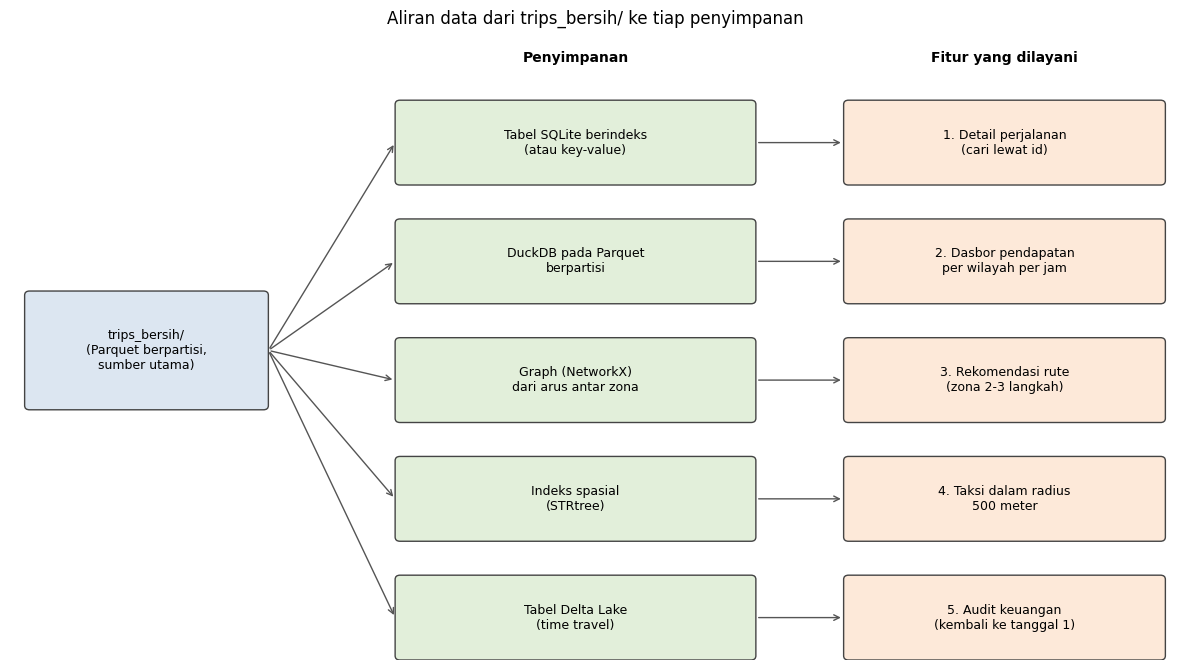

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

PILIHAN = [   # (fitur, cara menyimpan)
    ("1. Detail perjalanan\n(cari lewat id)",        "Tabel SQLite berindeks\n(atau key-value)"),
    ("2. Dasbor pendapatan\nper wilayah per jam",    "DuckDB pada Parquet\nberpartisi"),
    ("3. Rekomendasi rute\n(zona 2-3 langkah)",      "Graph (NetworkX)\ndari arus antar zona"),
    ("4. Taksi dalam radius\n500 meter",             "Indeks spasial\n(STRtree)"),
    ("5. Audit keuangan\n(kembali ke tanggal 1)",    "Tabel Delta Lake\n(time travel)"),
]

fig, ax = plt.subplots(figsize=(12, 6.8))
ax.set_xlim(0, 12); ax.set_ylim(0, 7.4); ax.axis("off")

def kotak_diagram(x, y, lebar, tinggi, teks, warna):
    ax.add_patch(FancyBboxPatch((x, y), lebar, tinggi, boxstyle="round,pad=0.05", fc=warna, ec="#444444"))
    ax.text(x + lebar / 2, y + tinggi / 2, teks, ha="center", va="center", fontsize=9)

kotak_diagram(0.2, 3.0, 2.4, 1.3, "trips_bersih/\n(Parquet berpartisi,\nsumber utama)", "#DCE6F1")
ax.text(5.8, 7.05, "Penyimpanan", ha="center", fontsize=10, fontweight="bold")
ax.text(10.2, 7.05, "Fitur yang dilayani", ha="center", fontsize=10, fontweight="bold")
for i, (fitur, simpan) in enumerate(PILIHAN):
    y = 6.1 - i * 1.4
    kotak_diagram(4.0, y - 0.45, 3.6, 0.9, simpan, "#E2EFDA")
    kotak_diagram(8.6, y - 0.45, 3.2, 0.9, fitur, "#FDE9D9")
    ax.annotate("", xy=(3.95, y), xytext=(2.65, 3.65), arrowprops=dict(arrowstyle="->", color="#555555"))
    ax.annotate("", xy=(8.55, y), xytext=(7.65, y), arrowprops=dict(arrowstyle="->", color="#555555"))
ax.set_title("Aliran data dari trips_bersih/ ke tiap penyimpanan", fontsize=12)
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/diagram_alur_penyimpanan.png", dpi=150)
plt.show()

# Tugas Praktikum
**Tugas 1 (Rekap benchmark):** `benchmark_nosql.csv` dan tabel rasio sudah dihasilkan pada K-9. Tulis satu kalimat interpretasi untuk tiap baris tabel rekap.

## Tugas 2: Data lain, cara lain (data: zona)

In [24]:
# Profil per zona jemput
profil_zona = (df.groupby("zona_jemput")
                 .agg(wilayah=("wilayah_jemput", "first"),
                      jumlah_jemput=("total_bayar", "size"),
                      rata_total_bayar=("total_bayar", "mean"))
                 .reset_index().rename(columns={"zona_jemput": "zona"}))
profil_zona["rata_total_bayar"] = profil_zona["rata_total_bayar"].round(2)
zona_contoh = int(profil_zona.sort_values(["jumlah_jemput", "zona"], ascending=[False, True])["zona"].iloc[0])
print("zona contoh (jemput terbanyak):", zona_contoh)

# ---------- Cara 1: TABEL (SQLite) ----------
con_z = sqlite3.connect(":memory:")
profil_zona.to_sql("zona", con_z, index=False)
tabel_mudah = con_z.execute("SELECT * FROM zona WHERE zona = ?", (zona_contoh,)).fetchone()
print("TABEL - mudah (profil satu zona):", tabel_mudah)

# canggung: zona yang terjangkau dalam 1-3 langkah -> setiap langkah menambah satu self-join
SQL_3 = f"""
SELECT tujuan FROM arus WHERE asal = {zona_contoh} AND jumlah >= {MIN}
UNION
SELECT a2.tujuan FROM arus a1 JOIN arus a2 ON a1.tujuan = a2.asal
 WHERE a1.asal = {zona_contoh} AND a1.jumlah >= {MIN} AND a2.jumlah >= {MIN}
UNION
SELECT a3.tujuan FROM arus a1 JOIN arus a2 ON a1.tujuan = a2.asal JOIN arus a3 ON a2.tujuan = a3.asal
 WHERE a1.asal = {zona_contoh} AND a1.jumlah >= {MIN} AND a2.jumlah >= {MIN} AND a3.jumlah >= {MIN}"""
tabel_canggung = {int(x) for x in con_d.sql(SQL_3).df()["tujuan"]} - {zona_contoh}
print("TABEL - canggung (<= 3 langkah, 2 self-join):", len(tabel_canggung), "zona")

# ---------- Cara 2: DOCUMENT (TinyDB) ----------
top5 = (arus.sort_values(["asal", "jumlah", "tujuan"], ascending=[True, False, True]).groupby("asal").head(5))
tujuan_teratas = {int(a): [{"zona": int(t), "jumlah": int(j)} for t, j in zip(g["tujuan"], g["jumlah"])]
                  for a, g in top5.groupby("asal")}
dok_z = TinyDB(storage=MemoryStorage).table("zona")
dok_z.insert_multiple([
    {"zona": int(r.zona), "wilayah": r.wilayah,
     "statistik": {"jumlah_jemput": int(r.jumlah_jemput), "rata_total_bayar": float(r.rata_total_bayar)},
     "tujuan_teratas": tujuan_teratas.get(int(r.zona), [])}
    for r in profil_zona.itertuples(index=False)])
print("DOKUMEN - mudah (profil + 5 tujuan teratas, satu kali baca):")
print(json.dumps(dok_z.get(Query().zona == zona_contoh), indent=1))

# canggung: jumlah jemput per wilayah -> harus membuka SEMUA dokumen dan menjumlahkan sendiri
per_wilayah_doc = {}
for d_ in dok_z.all():
    per_wilayah_doc[d_["wilayah"]] = per_wilayah_doc.get(d_["wilayah"], 0) + d_["statistik"]["jumlah_jemput"]
per_wilayah_sql = dict(con_z.execute("SELECT wilayah, SUM(jumlah_jemput) FROM zona GROUP BY wilayah").fetchall())
print("DOKUMEN - canggung (agregasi lintas dokumen) sama dengan SQL?", per_wilayah_doc == per_wilayah_sql)

# ---------- Cara 3: GRAPH (NetworkX) ----------
for r in profil_zona.itertuples(index=False):
    if G.has_node(int(r.zona)):
        G.nodes[int(r.zona)].update(wilayah=r.wilayah, jumlah_jemput=int(r.jumlah_jemput))
graf_mudah = set(nx.single_source_shortest_path_length(H, zona_contoh, cutoff=3)) - {zona_contoh}
print("GRAPH - mudah (<= 3 langkah, cukup ganti cutoff):", len(graf_mudah), "zona | sama dengan SQL?", graf_mudah == tabel_canggung)

# canggung: jumlah jemput per wilayah -> graph bukan alat untuk agregasi tabel
per_wilayah_graf = {}
for _, atr in G.nodes(data=True):
    if "jumlah_jemput" in atr:
        per_wilayah_graf[atr["wilayah"]] = per_wilayah_graf.get(atr["wilayah"], 0) + atr["jumlah_jemput"]
print("GRAPH - canggung (agregasi pada atribut node) sama dengan SQL?", per_wilayah_graf == per_wilayah_sql)

zona contoh (jemput terbanyak): 132
TABEL - mudah (profil satu zona): (132, 'Queens', 152840, 77.33)
TABEL - canggung (<= 3 langkah, 2 self-join): 214 zona
DOKUMEN - mudah (profil + 5 tujuan teratas, satu kali baca):
{
 "zona": 132,
 "wilayah": "Queens",
 "statistik": {
  "jumlah_jemput": 152840,
  "rata_total_bayar": 77.33
 },
 "tujuan_teratas": [
  {
   "zona": 230,
   "jumlah": 5835
  },
  {
   "zona": 265,
   "jumlah": 4942
  },
  {
   "zona": 48,
   "jumlah": 3945
  },
  {
   "zona": 10,
   "jumlah": 3397
  },
  {
   "zona": 93,
   "jumlah": 3141
  }
 ]
}
DOKUMEN - canggung (agregasi lintas dokumen) sama dengan SQL? True
GRAPH - mudah (<= 3 langkah, cukup ganti cutoff): 214 zona | sama dengan SQL? True
GRAPH - canggung (agregasi pada atribut node) sama dengan SQL? True


## Tugas 3: Delta Lake dua hari

In [25]:
PATH_2HARI = "/content/trips_delta_2hari"      # disk lokal Colab, diarsipkan ke Drive di sel terakhir
shutil.rmtree(PATH_2HARI, ignore_errors=True)

# ---------- HARI 1: menulis sebagian data ----------
write_deltalake(PATH_2HARI, data_delta.iloc[:60_000], mode="overwrite")
v_hari1 = DeltaTable(PATH_2HARI).version()
total_hari1 = float(DeltaTable(PATH_2HARI).to_pandas()["total_bayar"].sum())
print(f"Akhir hari 1 -> versi {v_hari1} | baris: 60.000 | total_bayar: {total_hari1:,.2f}")

# ---------- HARI 2: menambah data, lalu mengoreksi beberapa baris ----------
write_deltalake(PATH_2HARI, data_delta.iloc[60_000:90_000], mode="append")
dt2 = DeltaTable(PATH_2HARI)
gabung = data_delta.iloc[:90_000]
n_koreksi2 = int(((gabung["wilayah_jemput"] == "Manhattan") & (gabung["metode_bayar"] == "Tunai")).sum())
dt2.update(predicate="wilayah_jemput = 'Manhattan' AND metode_bayar = 'Tunai'",
           updates={"total_bayar": "total_bayar + 0.5"})
print(f"Akhir hari 2 -> versi {DeltaTable(PATH_2HARI).version()} | baris dikoreksi: {n_koreksi2}")

# ---------- Membaca tabel seperti keadaannya di akhir hari 1 ----------
akhir_hari1 = DeltaTable(PATH_2HARI, version=v_hari1).to_pandas()
terbaru2 = DeltaTable(PATH_2HARI).to_pandas()
print("baris akhir hari 1 (time travel):", len(akhir_hari1), "| baris terbaru:", len(terbaru2))
print("total_bayar akhir hari 1 sama dengan yang dicatat?", np.isclose(akhir_hari1["total_bayar"].sum(), total_hari1))

# ---------- Riwayat dan isi _delta_log/ ----------
for h in DeltaTable(PATH_2HARI).history():
    print(h.get("version"), h.get("operation"), pd.to_datetime(h.get("timestamp"), unit="ms"))

ringkas, txt = [], f"{DIR_SIMPAN}/isi_delta_log_2hari.txt"
with open(txt, "w", encoding="utf-8") as out:
    for nama in sorted(os.listdir(f"{PATH_2HARI}/_delta_log")):
        if not nama.endswith(".json"):
            continue
        isi = open(f"{PATH_2HARI}/_delta_log/{nama}", encoding="utf-8").read()
        out.write(f"===== {nama} =====\n{isi}\n")
        aksi = [json.loads(b) for b in isi.splitlines() if b.strip()]
        ringkas.append({"berkas": nama,
                        "operasi": next((a["commitInfo"].get("operation") for a in aksi if "commitInfo" in a), None),
                        "file ditambah": sum("add" in a for a in aksi),
                        "file dikeluarkan": sum("remove" in a for a in aksi)})
pd.DataFrame(ringkas)

Akhir hari 1 -> versi 0 | baris: 60.000 | total_bayar: 1,644,649.69
Akhir hari 2 -> versi 2 | baris dikoreksi: 13509
baris akhir hari 1 (time travel): 60000 | baris terbaru: 90000
total_bayar akhir hari 1 sama dengan yang dicatat? True
2 UPDATE 2026-10-08 12:42:04.731000
1 WRITE 2026-10-08 12:42:04.679000
0 WRITE 2026-10-08 12:42:04.648000


,berkas,operasi,file ditambah,file dikeluarkan
0,00000000000000000000.json,WRITE,1,0
1,00000000000000000001.json,WRITE,1,0
2,00000000000000000002.json,UPDATE,1,2


## Tugas 4: Pengumpulan
Laporan PDF dikerjakan terpisah. Jalankan sel di bawah untuk membuat arsip, lalu **Runtime → Restart session and run all** pada runtime bersih, dan pastikan tidak ada error sampai sel terakhir.

In [26]:
shutil.make_archive(f"{DIR_SIMPAN}/trips_delta", "zip", PATH_DELTA)
shutil.make_archive(f"{DIR_SIMPAN}/trips_delta_2hari", "zip", PATH_2HARI)
print(sorted(os.listdir(DIR_SIMPAN)))

['benchmark_nosql.csv', 'diagram_alur_penyimpanan.png', 'isi_delta_log_2hari.txt', 'rekap_rasio.csv', 'trips_delta', 'trips_delta.zip', 'trips_delta_2hari.zip']
